<a href="https://colab.research.google.com/github/ssarinbe24-sys/AI_for_Cybersecurity-/blob/main/Timestamp_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df= pd.read_csv('/content/ambient_temperature_system_failure.csv')

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  7267 non-null   object 
 1   value      7267 non-null   float64
dtypes: float64(1), object(1)
memory usage: 113.7+ KB
None


In [ ]:
print(df['timestamp'].head(10))

0    2013-07-04 00:00:00
1    2013-07-04 01:00:00
2    2013-07-04 02:00:00
3    2013-07-04 03:00:00
4    2013-07-04 04:00:00
5    2013-07-04 05:00:00
6    2013-07-04 06:00:00
7    2013-07-04 07:00:00
8    2013-07-04 08:00:00
9    2013-07-04 09:00:00
Name: timestamp, dtype: object


In [ ]:
import pandas as pd

# Calculate mean network traffic
mean_traffic = df["value"].mean()

print("value", mean_traffic)

value 71.24243270828815


<Axes: xlabel='timestamp'>

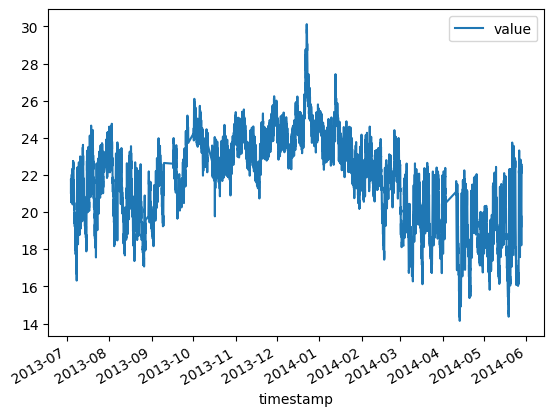

In [ ]:
df['timestamp']=pd.to_datetime(df['timestamp'])
df['value']=(df['value']-32)* 5/9
df.plot(x='timestamp',y='value')

In [ ]:
df['hours']=df['timestamp'].dt.hour


In [ ]:
df['daylight'] = (df['hours'] >= 7) & (df['hours'] <= 22)
df

,timestamp,value,hours,daylight
0,2013-07-04 00:00:00,21.044908,0,False
1,2013-07-04 01:00:00,21.789015,1,False
2,2013-07-04 02:00:00,21.598781,2,False
3,2013-07-04 03:00:00,20.533000,3,False
4,2013-07-04 04:00:00,20.713084,4,False
...,...,...,...,...
7262,2014-05-28 11:00:00,22.427892,11,True
7263,2014-05-28 12:00:00,22.318309,12,True
7264,2014-05-28 13:00:00,22.248092,13,True
7265,2014-05-28 14:00:00,22.125126,14,True


In [ ]:
df['day_type'] = df['timestamp'].dt.dayofweek.apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday')

In [ ]:
df

,timestamp,value,hours,daylight,day_type
0,2013-07-04 00:00:00,21.044908,0,False,Weekday
1,2013-07-04 01:00:00,21.789015,1,False,Weekday
2,2013-07-04 02:00:00,21.598781,2,False,Weekday
3,2013-07-04 03:00:00,20.533000,3,False,Weekday
4,2013-07-04 04:00:00,20.713084,4,False,Weekday
...,...,...,...,...,...
7262,2014-05-28 11:00:00,22.427892,11,True,Weekday
7263,2014-05-28 12:00:00,22.318309,12,True,Weekday
7264,2014-05-28 13:00:00,22.248092,13,True,Weekday
7265,2014-05-28 14:00:00,22.125126,14,True,Weekday


In [ ]:
df['day_of_week'] = df['timestamp'].dt.dayofweek
df

,timestamp,value,hours,daylight,day_type,day_of_week
0,2013-07-04 00:00:00,21.044908,0,False,Weekday,3
1,2013-07-04 01:00:00,21.789015,1,False,Weekday,3
2,2013-07-04 02:00:00,21.598781,2,False,Weekday,3
3,2013-07-04 03:00:00,20.533000,3,False,Weekday,3
4,2013-07-04 04:00:00,20.713084,4,False,Weekday,3
...,...,...,...,...,...,...
7262,2014-05-28 11:00:00,22.427892,11,True,Weekday,2
7263,2014-05-28 12:00:00,22.318309,12,True,Weekday,2
7264,2014-05-28 13:00:00,22.248092,13,True,Weekday,2
7265,2014-05-28 14:00:00,22.125126,14,True,Weekday,2


In [ ]:
print(df[df['day_type'] != 'Weekday'])

               timestamp      value  hours  daylight day_type  day_of_week
48   2013-07-06 00:00:00  22.017202      0     False  Weekend            5
49   2013-07-06 01:00:00  21.442631      1     False  Weekend            5
50   2013-07-06 02:00:00  21.584712      2     False  Weekend            5
51   2013-07-06 03:00:00  21.713760      3     False  Weekend            5
52   2013-07-06 04:00:00  21.581796      4     False  Weekend            5
...                  ...        ...    ...       ...      ...          ...
7198 2014-05-25 19:00:00  16.137000     19      True  Weekend            6
7199 2014-05-25 20:00:00  16.920085     20      True  Weekend            6
7200 2014-05-25 21:00:00  16.026475     21      True  Weekend            6
7201 2014-05-25 22:00:00  16.756677     22      True  Weekend            6
7202 2014-05-25 23:00:00  16.373580     23     False  Weekend            6

[2024 rows x 6 columns]


In [ ]:
import numpy as np
df['time_epoch']=(df['timestamp'].astype(np.int64)/1000000000000).astype(np.int64)
df

,timestamp,value,hours,daylight,day_type,day_of_week,time_epoch
0,2013-07-04 00:00:00,21.044908,0,False,Weekday,3,1372896
1,2013-07-04 01:00:00,21.789015,1,False,Weekday,3,1372899
2,2013-07-04 02:00:00,21.598781,2,False,Weekday,3,1372903
3,2013-07-04 03:00:00,20.533000,3,False,Weekday,3,1372906
4,2013-07-04 04:00:00,20.713084,4,False,Weekday,3,1372910
...,...,...,...,...,...,...,...
7262,2014-05-28 11:00:00,22.427892,11,True,Weekday,2,1401274
7263,2014-05-28 12:00:00,22.318309,12,True,Weekday,2,1401278
7264,2014-05-28 13:00:00,22.248092,13,True,Weekday,2,1401282
7265,2014-05-28 14:00:00,22.125126,14,True,Weekday,2,1401285


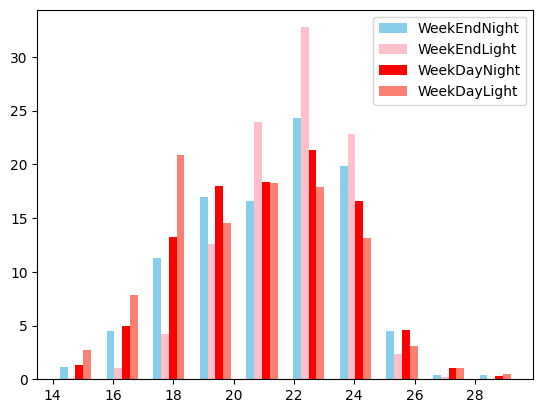

In [ ]:
import matplotlib.pyplot as plt

#creation of 4 distinct categories that seem useful(week end/day week & night/day)
# Convert 'day_type' to numerical (0 for Weekday, 1 for Weekend)
day_type_numeric = df['day_type'].apply(lambda x: 0 if x == 'Weekday' else 1)
# Convert 'daylight' (boolean) to numerical (0 for False, 1 for True)
daylight_numeric = df['daylight'].astype(int)

df['categories'] = day_type_numeric * 2 + daylight_numeric

a= df.loc[df['categories']== 0,'value']
b= df.loc[df['categories']== 1,'value']
c= df.loc[df['categories']== 2,'value']
d= df.loc[df['categories']== 3,'value']

fig,ax=plt.subplots()
a_heights,a_bins=np.histogram(a)
b_heights,b_bins=np.histogram(b,bins=a_bins)
c_heights,c_bins=np.histogram(c,bins=a_bins)
d_heights,d_bins=np.histogram(d,bins=a_bins)

width=(a_bins[1]-a_bins[0])/6

ax.bar(a_bins[:-1],a_heights*100/a.count(),width=width, facecolor='skyblue',label="WeekEndNight")
ax.bar(b_bins[:-1]+width,(b_heights*100/b.count()),width=width, facecolor='pink',label="WeekEndLight")
ax.bar(c_bins[:-1]+width*2,(c_heights*100/c.count()),width=width, facecolor='red',label="WeekDayNight")
ax.bar(d_bins[:-1]+width*3,(d_heights*100/d.count()),width=width, facecolor='salmon',label="WeekDayLight")

plt.legend()
plt.show(block=True)

In [ ]:
df['day_type']=df['day_type'].apply(lambda x: 0 if x == 'Weekday' else 1)
df['day_of_week']=df['day_of_week'].apply(lambda x: 0 if x == 'Weekday' else 1)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd # Ensure pandas is imported if not already globally available

#take useful features and standardize them
initial_features = ['value','hours','daylight','day_of_week','day_type']
data=df[initial_features] # Changed 'day_type_numeric' to 'day_type'
min_max_scaler=StandardScaler()
np_scaled=min_max_scaler.fit_transform(data)
data=pd.DataFrame(np_scaled, columns=initial_features) # Retain all features for PCA

#reduce to 2 importants features
pca=PCA(n_components=2)
data=pca.fit_transform(data)
#standardize these 2 new features
min_max_scaler=StandardScaler()
np_scaled=min_max_scaler.fit_transform(data)
data=pd.DataFrame(np_scaled)

In [ ]:
from sklearn.cluster import KMeans # Import KMeans

kmeans_model = KMeans(n_clusters=14, random_state=42, n_init=10) # Instantiate KMeans
df['cluster'] = kmeans_model.fit_predict(data) # Use fit_predict on the 'data' (principal components)
df['principal_feature1'] = data[0]
df['principal_feature2'] = data[1]
df['cluster'].value_counts()

,count
cluster,
3,983
4,920
9,699
1,624
10,560
0,541
12,522
8,414
7,396


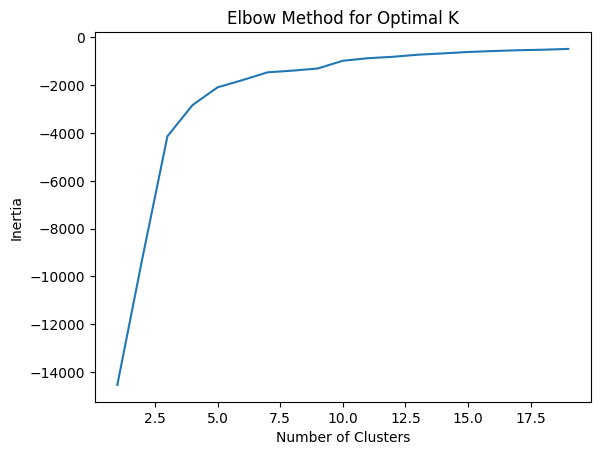

In [ ]:
from sklearn.cluster import KMeans
n_cluster = range(1,20)

# Convert column names to strings to avoid TypeError
data.columns = data.columns.astype(str)

kmeans = [KMeans(n_clusters=i, random_state=0, n_init='auto').fit(data) for i in n_cluster]
scores = [kmeans[i].score(data) for i in range(len(kmeans))]
fig, ax = plt.subplots()
ax.plot(n_cluster  , scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

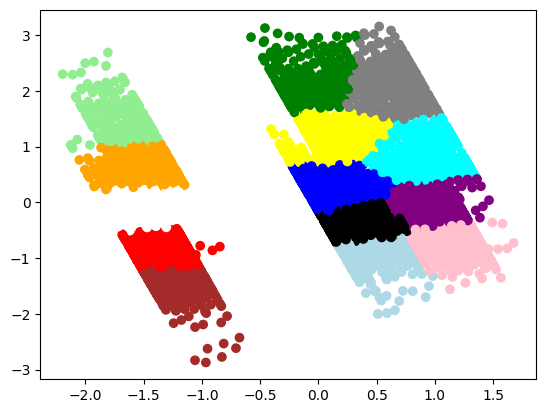

In [ ]:
import matplotlib.pyplot as plt
fig, ax=plt.subplots()
colors={0:'red',1:'blue',2:'green',3:'pink',4:'black',5:'orange',6:'cyan',7:'yellow'
,8:'brown',9:'purple',10:'white',11:'grey',12:'lightblue',13:'lightgreen',14:'darkgrey'}
ax.scatter(df['principal_feature1'],df['principal_feature2'],c=df['cluster'].
              apply(lambda x:colors[x]))
plt.show()

In [ ]:
import numpy as np # Ensure numpy is imported

# Define outliers_fraction if not already defined
outliers_fraction = 0.01 # Example value, can be adjusted based on domain knowledge

# Get the distance between each point and its neareast centroid
# Use kmeans_model.transform(data) to get distances to all centroids, then take the minimum
distance = np.min(kmeans_model.transform(data), axis=1)

# Corrected typo from 'numer_of_outliers' to 'number_of_outliers'
number_of_outliers=int(outliers_fraction*len(distance))

#convert the distance array to a Pandas Series
distance_series=pd.Series(distance)

#Find the threshold for anomalies
threshold=distance_series.nlargest(number_of_outliers).min()

#Assign anomaly labels
df['anomaly21']=(distance_series>=threshold).astype(int)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(


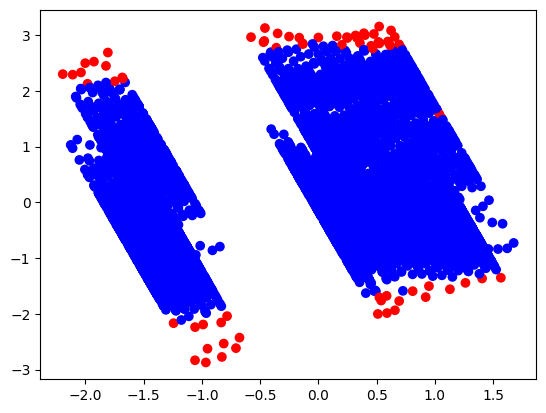

In [ ]:
#visualtisation of anaomly with cluster view
fig, ax=plt.subplots()
colors={0:'blue',1:'red'}
ax.scatter(df['principal_feature1'],df['principal_feature2'],c=df['anomaly21'].
           apply(lambda x:colors[x]))
plt.show()


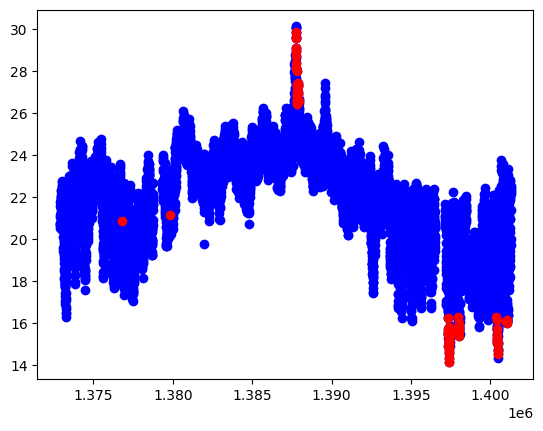

In [ ]:
#visualisation of anomaly throughout time (viz 1)
fig, ax=plt.subplots()

a= df.loc[df['anomaly21']==1,['time_epoch','value']] #anomaly

ax.scatter(df['time_epoch'],df['value'],color='blue')
ax.scatter(a['time_epoch'],a['value'],color='red')
plt.show()

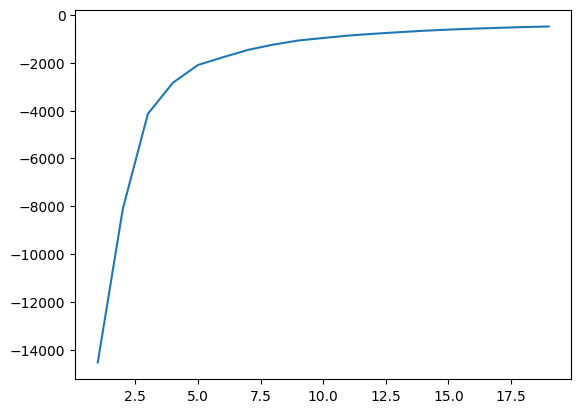

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

n_cluster = range(1,20)
kmeans = [KMeans(n_clusters=i, n_init=10, random_state=0).fit(data) for i in n_cluster]
scores = [kmeans[i].score(data) for i in range(len(kmeans))]
fig, ax  = plt.subplots()
ax.plot(n_cluster, scores)
plt.show()

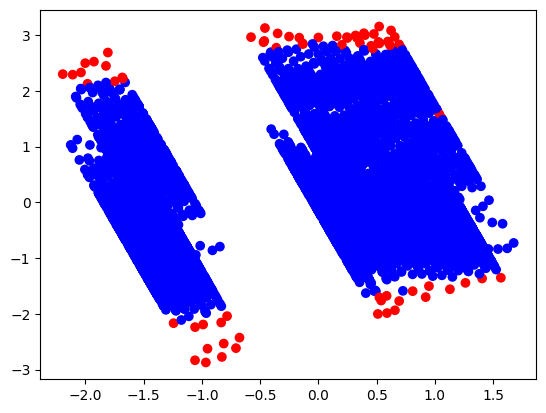

In [ ]:
# visualisation of anomaly with cluster view
fig, ax = plt.subplots()
colors = {0:'blue', 1:'red'}
ax.scatter(df['principal_feature1'], df['principal_feature2'], c=df["anomaly21"].
           apply(lambda x: colors[x]))
plt.show()

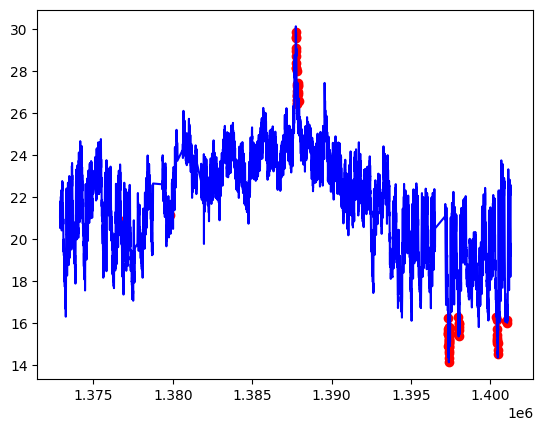

In [ ]:
# visualisation of anomaly throughout time (viz 1)
fig, ax = plt.subplots()

a = df.loc[df['anomaly21'] == 1, ['time_epoch', 'value']] #anomaly

ax.plot(df['time_epoch'], df['value'], color='blue')
ax.scatter(a['time_epoch'],a['value'], color='red')
plt.show()

/tmp/ipykernel_2488/403582798.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


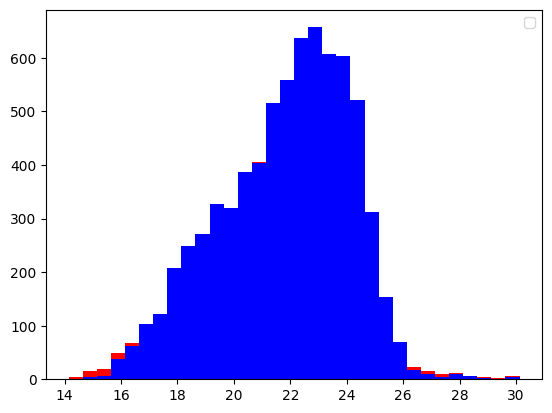

In [ ]:
# visualisation of anomaly with temperature repartition (viz 2)
a = df.loc[df['anomaly21'] == 0, 'value']
b = df.loc[df['anomaly21'] == 1, 'value']

fig, axs = plt.subplots()
axs.hist([a,b], bins=32, stacked=True, color=['blue', 'red'])
plt.legend()
plt.show()